In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')
sys.path.append('./SALSA-CLRS/')

import torch
from model.GINE import GINE

from loguru import logger
from baselines.core.models.encoder import Encoder
from baselines.core.models.decoder import Decoder
from baselines.core.loss import CLRSLoss
from salsaclrs import specs

device = torch.device('cuda')

K = 10000
circuit_algorithm = 'greedy'
prune = True

c:\Users\heje197\AppData\Local\miniconda3\envs\minar\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\heje197\AppData\Local\miniconda3\envs\minar\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
from EncodeProcessDecode import EncodeProcessDecode
algorithms = ['bfs', 'dfs', 'dijkstra', 'mst_prim', 'bellman_ford', 'articulation_points', 'bridges']
algorithms_plotting = ['BFS', 'DFS', 'Dijkstra', 'Prim\'s MST', 'Bellman-Ford', 'Articulation Points', 'Bridges']
output_types = {
    'bfs' : 'pointer',
    'dfs' : 'pointer',
    'dijkstra' : 'pointer',
    'mst_prim' : 'pointer',
    'bellman_ford' : 'pointer',
    'articulation_points' : 'mask',
    'bridges' : 'edge_mask',
}
accuracy_types = {
    'bfs' : 'node_accuracy',
    'dfs' : 'node_accuracy',
    'dijkstra' : 'node_accuracy',
    'mst_prim' : 'node_accuracy',
    'bellman_ford' : 'node_accuracy',
    'articulation_points' : 'node_accuracy',
    'bridges' : 'edge_accuracy',
}
logger.disable('baselines.core.models.encoder')
logger.disable('baselines.core.models.decoder')

hidden_dim = 128
encoders = torch.nn.ModuleDict({
    task : Encoder(specs=specs.SPECS[task]) for task in algorithms
})

decoders = torch.nn.ModuleDict({
    task : Decoder(specs=specs.SPECS[task], 
                   hidden_dim = hidden_dim * 2,
                   no_hint=False) for task in algorithms
})

for encoder in encoders.values():
    encoder.to(device)
for decoder in decoders.values():
    decoder.to(device)
processor = GINE(3*128, 128, 2, 128, edge_dim=1, aggr='max')
processor.to(device)
model = EncodeProcessDecode(encoders, decoders, processor, device=device)

model_checkpoint = f'model_in_progress_199'
model_state = torch.load(f'checkpoints/{model_checkpoint}.pt', map_location=device)
model.load_state_dict(model_state)
model.eval()
model.to(device)

EncodeProcessDecode(
  (encoders): ModuleDict(
    (bfs): Encoder(
      (encoder): ModuleDict(
        (pos): NodeBaseEncoder(
          (lin): Linear(in_features=1, out_features=128, bias=True)
        )
        (s): NodeBaseEncoder(
          (lin): Linear(in_features=1, out_features=128, bias=True)
        )
      )
    )
    (dfs): Encoder(
      (encoder): ModuleDict(
        (pos): NodeBaseEncoder(
          (lin): Linear(in_features=1, out_features=128, bias=True)
        )
      )
    )
    (dijkstra): Encoder(
      (encoder): ModuleDict(
        (pos): NodeBaseEncoder(
          (lin): Linear(in_features=1, out_features=128, bias=True)
        )
        (s): NodeBaseEncoder(
          (lin): Linear(in_features=1, out_features=128, bias=True)
        )
      )
    )
    (mst_prim): Encoder(
      (encoder): ModuleDict(
        (pos): NodeBaseEncoder(
          (lin): Linear(in_features=1, out_features=128, bias=True)
        )
        (s): NodeBaseEncoder(
          (lin): Li

In [3]:
clean_directory = './data_clean/'
corrupted_directory = './data_corrupted/'
random_directory = './data_random/'

num_samples = 128
clean_data = {algorithm : [torch.load(f'{clean_directory}/{algorithm}/data_{i}.pt', weights_only=False) for i in range(num_samples)] for algorithm in algorithms}
corrupted_data = {algorithm : [torch.load(f'{corrupted_directory}/{algorithm}/data_{i}.pt', weights_only=False) for i in range(num_samples)] for algorithm in algorithms}
random_data = {algorithm : [torch.load(f'{random_directory}/{algorithm}/data_{i}.pt', weights_only=False) for i in range(num_samples)] for algorithm in algorithms}
criteria = {algorithm : CLRSLoss(specs=specs.SPECS[algorithm], hidden_loss_type='l2') for algorithm in algorithms}

In [4]:
# Get model baseline performance and embeddings
from salsaclrs.data import SALSACLRSDataLoader
from baselines.core.metrics import calc_metrics

try:
    acc_model = torch.load(f'metrics/acc_model_new_{model_checkpoint}.pt', weights_only=False)
except:
    acc_model = {}
    for task in algorithms:
        loader = SALSACLRSDataLoader(clean_data[task], batch_size=32, shuffle=False)
        avg_model_acc = 0
        for data in loader:
            data.to(model.device)
            if hasattr(data, 'weights'):
                data.edge_attr = data.weights.unsqueeze(1)
            else:
                data.edge_attr = torch.zeros((data.num_edges, 1), device=model.device)
            data.task = task
            out, _, hidden = model(data)
            if task == 'bridges':
                model_accuracy = calc_metrics(data.outputs[0], out, data, output_types[task])['edge_accuracy'].mean().item()
            else:
                model_accuracy = calc_metrics(data.outputs[0], out, data, output_types[task])['node_accuracy'].mean().item()
            avg_model_acc += model_accuracy / len(loader)
        acc_model[task] = avg_model_acc
    torch.save(acc_model, f'metrics/acc_model_new_{model_checkpoint}.pt')

In [5]:
import os
from SALSACLRSComputationGraph import SALSACLRSComputationGraph
import networkx as nx
compute_scores = ['weight_grad', 'EAP', 'EAP-IG']
score_methods_plotting = ['Weight-Grad', 'EAP', 'EAP-IG']

G = SALSACLRSComputationGraph(model, special_modules=['convs.0.lin', 'convs.1.lin'])
G.add_module('convs.0.lin', processor.convs[0].lin,
            module_inputs='edge_attr',
            module_outputs=0,
            layer=0)
G.add_module('convs.1.lin', processor.convs[1].lin,
            module_inputs='edge_attr',
            module_outputs=2,
            layer=0)
G.correct_layers()
print(G.number_of_edges())

G_save_string = f'G_scores_new_{model_checkpoint}.pt'
G_scores = torch.load(f'scored_computation_graphs/{G_save_string}', weights_only=False)
for edge, data in G_scores.items():
    G.add_edge(*edge, **data)
print(f'Loaded existing scored computation graph from scored_computation_graphs/{G_save_string}')

G_random = SALSACLRSComputationGraph(model, special_modules=['convs.0.lin', 'convs.1.lin'])
G_random.add_module('convs.0.lin', processor.convs[0].lin,
            module_inputs='edge_attr',
            module_outputs=0,
            layer=0)
G_random.add_module('convs.1.lin', processor.convs[1].lin,
            module_inputs='edge_attr',
            module_outputs=2,
            layer=0)
G_random.correct_layers()
G_random_save_string = f'G_random_scores_new_{model_checkpoint}.pt'

if os.path.exists(f'scored_computation_graphs/{G_random_save_string}'):
    G_random_scores = torch.load(f'scored_computation_graphs/{G_random_save_string}', weights_only=False)
    for edge, data in G_random_scores.items():
        G_random.add_edge(*edge, **data)
    print(f'Loaded existing scored random computation graph from scored_computation_graphs/{G_random_save_string}')
else:
    print('Creating new random computation graph...')
    for algorithm in algorithms:
        for score_method in compute_scores:
            if score_method == 'EAP-IG':
                print(f'Calculating {score_method} scores for {algorithm}...')
                G_random.calculate_scores(algorithm, clean_data[algorithm], random_data[algorithm], criteria[algorithm], which=score_method, **{'steps': 20})
            else:
                print(f'Calculating {score_method} scores for {algorithm}...')
                G_random.calculate_scores(algorithm, clean_data[algorithm], random_data[algorithm], criteria[algorithm], which=score_method)

    # Only save the scores since saving the whole objects pickles the model
    G_random_scores = {(u,v) : data for u, v, data in G_random.edges(data=True)}
    torch.save(G_random_scores, f'scored_computation_graphs/{G_random_save_string}')

99712
Loaded existing scored computation graph from scored_computation_graphs/G_scores_new_model_in_progress_199.pt
Loaded existing scored random computation graph from scored_computation_graphs/G_random_scores_new_model_in_progress_199.pt


In [6]:
from SALSACLRSComputationGraph import SALSACLRSCircuit

score_methods = ['weight_grad', 'EAP', 'EAP-IG']
circuit_path = f'salsa_clrs_circuits_greedy_new_prune=True_{model_checkpoint}.pt'
circuits = torch.load(f'circuits/{circuit_path}', weights_only=False)
for circuit in circuits.values():
    circuit.G = G
    circuit.EncodeProcessDecode = model
    circuit.model = processor

In [7]:
random_circuit_path = f'salsa_clrs_random_circuits_greedy_new_prune=True_{model_checkpoint}.pt'
if os.path.exists(f'circuits/{random_circuit_path}'):
    random_circuits = torch.load(f'circuits/{random_circuit_path}', weights_only=False)
else:
    random_circuits = {}

for algorithm in algorithms:
    for score_method in score_methods:
        if (algorithm, K, score_method) in random_circuits:
            print(f'Circuit for {algorithm} with K={K} and score method {score_method} already exists. Skipping...')
            skipped = True
        else:
            random_circuits[(algorithm, K, score_method)] = SALSACLRSCircuit(model, G, K, key=f'{score_method}_{algorithm}', circuit_algorithm=circuit_algorithm, prune=prune)
            print(f'{algorithm} circuit with K={K} and score method {score_method}: {random_circuits[(algorithm, K, score_method)].number_of_edges()} edges')
        if not skipped:
            for circuit in random_circuits.values():
                circuit.G = None
                circuit.model = None
                circuit.EncodeProcessDecode = None
            torch.save(random_circuits, f'circuits/{random_circuit_path}')
for circuit in random_circuits.values():
    circuit.G = G
    circuit.EncodeProcessDecode = model
    circuit.model = processor

Circuit for bfs with K=10000 and score method weight_grad already exists. Skipping...
Circuit for bfs with K=10000 and score method EAP already exists. Skipping...
Circuit for bfs with K=10000 and score method EAP-IG already exists. Skipping...
Circuit for dfs with K=10000 and score method weight_grad already exists. Skipping...
Circuit for dfs with K=10000 and score method EAP already exists. Skipping...
Circuit for dfs with K=10000 and score method EAP-IG already exists. Skipping...
Circuit for dijkstra with K=10000 and score method weight_grad already exists. Skipping...
Circuit for dijkstra with K=10000 and score method EAP already exists. Skipping...
Circuit for dijkstra with K=10000 and score method EAP-IG already exists. Skipping...
Circuit for mst_prim with K=10000 and score method weight_grad already exists. Skipping...
Circuit for mst_prim with K=10000 and score method EAP already exists. Skipping...
Circuit for mst_prim with K=10000 and score method EAP-IG already exists. Sk

In [8]:
from salsaclrs.data import SALSACLRSDataLoader
from baselines.core.metrics import calc_metrics

acc_model = torch.load(f'metrics/acc_circuit_greedy_new_prune=True_{model_checkpoint}.pt', weights_only=False)
acc_circuit = torch.load(f'metrics/acc_circuit_greedy_new_prune=True_{model_checkpoint}.pt', weights_only=False)
acc_ablate = torch.load(f'metrics/acc_ablate_greedy_new_prune=True_{model_checkpoint}.pt', weights_only=False)
fid_circuit = torch.load(f'metrics/fid_circuit_greedy_new_prune=True_{model_checkpoint}.pt', weights_only=False)
fid_ablate = torch.load(f'metrics/fid_ablate_greedy_new_prune=True_{model_checkpoint}.pt', weights_only=False)

try:
    acc_circuit_random = torch.load(f'metrics/acc_circuit_random_greedy_new_prune=True_{model_checkpoint}.pt', weights_only=False)
    acc_ablate_random = torch.load(f'metrics/acc_ablate_random_greedy_new_prune=True_{model_checkpoint}.pt', weights_only=False)
    fid_circuit_random = torch.load(f'metrics/fid_circuit_random_greedy_new_prune=True_{model_checkpoint}.pt', weights_only=False)
    fid_ablate_random = torch.load(f'metrics/fid_ablate_random_greedy_new_prune=True_{model_checkpoint}.pt', weights_only=False)
except:
    acc_circuit_random = {}
    acc_ablate_random = {}
    fid_circuit_random = {}
    fid_ablate_random = {}

batch_size = 32
for task in algorithms:
    print(f'Calculating metrics for {task}...')
    loader = SALSACLRSDataLoader(clean_data[task], batch_size=batch_size, shuffle=False)
    for score_method in score_methods:
        if (task, K, score_method) in acc_circuit_random:
            print(f'Metrics for {task} with K={K} and score method {score_method} already exists. Skipping...')
            continue
        circuit = circuits[(task, K, score_method)]
        avg_acc_circuit_random = 0
        avg_acc_ablate_random = 0
        avg_fid_circuit_random = 0
        avg_fid_ablate_random = 0
        for data in loader:
            data.to(device)
            if hasattr(data, 'weights'):
                data.edge_attr = data.weights.unsqueeze(1)
            else:
                data.edge_attr = torch.zeros((data.num_edges, 1), device=device)
            data.task = task

            # Original model
            out_model, _, _ = model(data)
            data_compare = data.clone()
            for output in data_compare.outputs:
                if task == 'articulation_points' or task == 'bridges':
                    data_compare.outputs = out_model[output].detach() > 0
                else:
                    data_compare.outputs = out_model[output].detach()

            # Circuit model
            out_circuit, _, _ = circuit.forward(data)
            out_ablate, _, _ = circuit.ablate_circuit(data)

            circuit_accuracy = calc_metrics(data.outputs[0], out_circuit, data, output_types[task])[accuracy_types[task]].mean().item()
            ablate_accuracy = calc_metrics(data.outputs[0], out_ablate, data, output_types[task])[accuracy_types[task]].mean().item()
            circuit_fid = calc_metrics(data.outputs[0], out_circuit, data_compare, output_types[task])[accuracy_types[task]].mean().item()
            ablate_fid = calc_metrics(data.outputs[0], out_ablate, data_compare, output_types[task])[accuracy_types[task]].mean().item()

            avg_acc_circuit_random += circuit_accuracy
            avg_acc_ablate_random += ablate_accuracy
            avg_fid_circuit_random += circuit_fid
            avg_fid_ablate_random += ablate_fid

        circuit_accs = avg_acc_circuit_random / len(loader)
        ablate_accs = avg_acc_ablate_random / len(loader)
        circuit_fids = 1 - avg_fid_circuit_random / len(loader)
        ablate_fids = 1 - avg_fid_ablate_random / len(loader)

        print(f'Task: {task}, K: {K}, Score: {score_method} | Circuit Acc: {circuit_accs:.4f}, Ablate Acc: {ablate_accs:.4f}, Circuit Fid: {circuit_fids:.6f}, Ablate Fid: {ablate_fids:.6f}')
        acc_circuit_random[(task, K, score_method)] = circuit_accs
        acc_ablate_random[(task, K, score_method)] = ablate_accs
        fid_circuit_random[(task, K, score_method)] = circuit_fids
        fid_ablate_random[(task, K, score_method)] = ablate_fids
torch.save(acc_circuit_random, f'metrics/acc_circuit_random_greedy_new_prune=True_{model_checkpoint}.pt')
torch.save(acc_ablate_random, f'metrics/acc_ablate_random_greedy_new_prune=True_{model_checkpoint}.pt')
torch.save(fid_circuit_random, f'metrics/fid_circuit_random_greedy_new_prune=True_{model_checkpoint}.pt')
torch.save(fid_ablate_random, f'metrics/fid_ablate_random_greedy_new_prune=True_{model_checkpoint}.pt')

Calculating metrics for bfs...
Metrics for bfs with K=10000 and score method weight_grad already exists. Skipping...
Metrics for bfs with K=10000 and score method EAP already exists. Skipping...
Metrics for bfs with K=10000 and score method EAP-IG already exists. Skipping...
Calculating metrics for dfs...
Metrics for dfs with K=10000 and score method weight_grad already exists. Skipping...
Metrics for dfs with K=10000 and score method EAP already exists. Skipping...
Metrics for dfs with K=10000 and score method EAP-IG already exists. Skipping...
Calculating metrics for dijkstra...
Metrics for dijkstra with K=10000 and score method weight_grad already exists. Skipping...
Metrics for dijkstra with K=10000 and score method EAP already exists. Skipping...
Metrics for dijkstra with K=10000 and score method EAP-IG already exists. Skipping...
Calculating metrics for mst_prim...
Metrics for mst_prim with K=10000 and score method weight_grad already exists. Skipping...
Metrics for mst_prim with

In [9]:
def characterization_score(circuit_fid, ablate_fid, w_circuit=0.5, w_ablate=0.5):
    assert w_circuit + w_ablate == 1.0, "Weights must sum to 1."
    if circuit_fid == 0 or ablate_fid == 0:
        return 0.0
    return 1 / (w_circuit / (1-circuit_fid) + w_ablate / ablate_fid)
circuit_char_scores = torch.load(f'metrics/char_scores_circuit_greedy_new_prune=True_{model_checkpoint}.pt', weights_only=False)
random_char_scores = {}
for task in algorithms:
    for score_method in score_methods:
        circuit_fid = fid_circuit.get((task, K, score_method))
        ablate_fid = fid_ablate.get((task, K, score_method))
        char_score = characterization_score(circuit_fid, ablate_fid)
        random_char_scores[(task, K, score_method)] = char_score
torch.save(random_char_scores, f'metrics/random_char_scores_circuit_greedy_new_prune=True_{model_checkpoint}.pt')

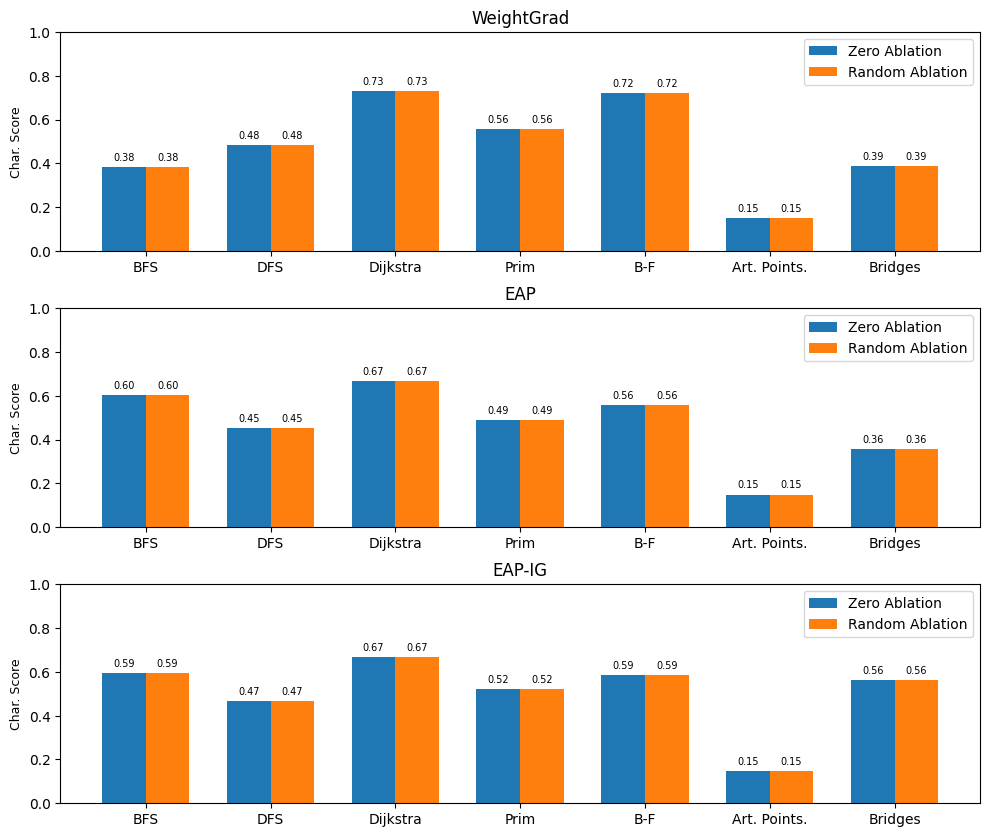

In [22]:
from matplotlib import pyplot as plt
import numpy as np
score_methods = ['weight_grad', 'EAP', 'EAP-IG']
score_methods_plotting = ['WeightGrad', 'EAP', 'EAP-IG']
algorithms_plotting = ['BFS', 'DFS', 'Dijkstra', 'Prim', 'B-F', 'Art. Points.', 'Bridges']

# Plot: rows = score methods, cols = tasks
K = 10000
n_rows = len(score_methods)
n_cols = len(algorithms)

# Create 3 grouped bar plots (one per score method)
fig, axes = plt.subplots(len(score_methods), 1, figsize=(10, len(score_methods)*3), sharey=True)

width = 0.35
x = np.arange(len(algorithms))

for i, score_method in enumerate(score_methods):
    ax = axes[i]
    c_vals, r_vals = [], []
    c_present, r_present = [], []
    for task in algorithms:
        key = (task, K, score_method)
        c = circuit_char_scores.get(key, None)
        r = random_char_scores.get(key, None)
        c_vals.append(c if c is not None else 0.0)
        r_vals.append(r if r is not None else 0.0)
        c_present.append(c is not None)
        r_present.append(r is not None)

    bars_c = ax.bar(x - width/2, c_vals, width, color='#1f77b4')
    bars_r = ax.bar(x + width/2, r_vals, width, color='#ff7f0e')

    for idx, b in enumerate(bars_c):
        if not c_present[idx]:
            b.set_alpha(0.3)
        label = f"{c_vals[idx]:.2f}" if c_present[idx] else "n/a"
        ax.text(b.get_x() + b.get_width()/2, c_vals[idx] + 0.02, label, ha='center', va='bottom', fontsize=7)

    for idx, b in enumerate(bars_r):
        if not r_present[idx]:
            b.set_alpha(0.3)
        label = f"{r_vals[idx]:.2f}" if r_present[idx] else "n/a"
        ax.text(b.get_x() + b.get_width()/2, r_vals[idx] + 0.02, label, ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(algorithms_plotting)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Char. Score', fontsize=9)
    ax.set_title(score_methods_plotting[i])
    ax.legend(['Zero Ablation', 'Random Ablation'], loc='upper right')

# fig.suptitle(f'Characterization Score by Score Method (K={K}, Greedy)')
plt.tight_layout()
plt.subplots_adjust(top=0.9)

plt.savefig(f'figures/zero_vs_random_by_method_new.png', dpi=300, bbox_inches='tight')
plt.savefig(f'figures/zero_vs_random_by_method_new.pdf', bbox_inches='tight')
plt.show()